# DeepCoder Pipeline – Schritt für Schritt

Dieses Notebook orchestriert `deepcoder_pipeline/scripts/` genau wie
`run_all.sh`, aber Zelle für Zelle — so wie
`DreamCoder_Train_Test_Workflow.ipynb` (`dreamcoder_train_test_pipeline_step_by_step`)
die DreamCoder-Pipeline Schritt für Schritt ausführt. Jeder Schritt läuft als
eigener Subprozess, sein Output wird live angezeigt und in `output/logs/`
protokolliert. Danach kannst du die erzeugten Dateien direkt im Notebook
prüfen, bevor du weitergehst.

Muss im Ordner `deepcoder_pipeline/` liegen und mit dem Kernel des
`deepcoder`-`.venv` (Python 3.9, TensorFlow/Keras 2.12) ausgeführt werden.


In [1]:
from pathlib import Path
import os, sys, subprocess, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
print("Aktueller Ordner:", ROOT)
print("Dateien:", sorted(p.name for p in ROOT.iterdir()))

assert (ROOT / "scripts").exists(), "Der Ordner scripts fehlt. Notebook im deepcoder_pipeline-Ordner ausführen."


Aktueller Ordner: C:\BA\deepcoder\deepcoder_pipeline
Dateien: ['README.md', 'deepcoder_metric_analysis.ipynb', 'output', 'run_all.sh', 'scripts']


## 0. Konfiguration

Hier stellst du ein, welcher Datensatz (`T`), welches Suchbudget (`gas`) und wie viele Trainingsepochen benutzt werden.

In [2]:
T = 2
GAS = 1000
EPOCHS = 10
SEED = 42  # fester Seed fuer reproduzierbares Training (siehe train-nn.py)

PYTHON = sys.executable
DEEPCODER_REPO_ROOT = ROOT.parent
TRAIN_PATH = DEEPCODER_REPO_ROOT / "dataset" / f"T={T}_train.json"
TEST_PATH = DEEPCODER_REPO_ROOT / "dataset" / f"T={T}_test.json"

OUTPUT_DIR = ROOT / "output"
LOG_DIR = OUTPUT_DIR / "logs"
OUTPUT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

ENV = os.environ.copy()
ENV["PYTHONPATH"] = str(DEEPCODER_REPO_ROOT)

NO_PRED_H5 = OUTPUT_DIR / f"results_T{T}_gas{GAS}_no_predictor.h5"
NO_PRED_CSV = OUTPUT_DIR / f"results_T{T}_gas{GAS}_no_predictor.csv"
NO_PRED_METRICS = OUTPUT_DIR / f"results_T{T}_gas{GAS}_no_predictor_compute_metrics.csv"
WITH_PRED_H5 = OUTPUT_DIR / f"results_T{T}_gas{GAS}_with_predictor.h5"
WITH_PRED_CSV = OUTPUT_DIR / f"results_T{T}_gas{GAS}_with_predictor.csv"
WITH_PRED_METRICS = OUTPUT_DIR / f"results_T{T}_gas{GAS}_with_predictor_compute_metrics.csv"
MODEL_FILE = OUTPUT_DIR / f"model_T{T}.h5"

print("PYTHON:", PYTHON)
print("DEEPCODER_REPO_ROOT:", DEEPCODER_REPO_ROOT)
print("T:", T, " GAS:", GAS, " EPOCHS:", EPOCHS, " SEED:", SEED)
print("TRAIN_PATH:", TRAIN_PATH, TRAIN_PATH.exists())
print("TEST_PATH:", TEST_PATH, TEST_PATH.exists())

assert TRAIN_PATH.exists(), "Trainingsdatensatz fehlt."
assert TEST_PATH.exists(), "Testdatensatz fehlt."


PYTHON: C:\BA\deepcoder\.venv\Scripts\python.exe
DEEPCODER_REPO_ROOT: C:\BA\deepcoder
T: 2  GAS: 1000  EPOCHS: 10  SEED: 42
TRAIN_PATH: C:\BA\deepcoder\dataset\T=2_train.json True
TEST_PATH: C:\BA\deepcoder\dataset\T=2_test.json True


## Hilfsfunktion zum Ausführen eines Schritts

Streamt den Output eines Pipeline-Skripts live ins Notebook und schreibt ihn zusätzlich nach `output/logs/`.

In [3]:
def run_step(name, cmd, log_name=None):
    log_name = log_name or f"{name}.log"
    log_path = LOG_DIR / log_name
    print("\n" + "=" * 80)
    print(name)
    print("Command:", " ".join(map(str, cmd)))
    print("Log:", log_path)
    print("=" * 80 + "\n")
    with open(log_path, "w", encoding="utf-8") as f:
        process = subprocess.Popen(
            list(map(str, cmd)),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            encoding="utf-8",
            errors="replace",
            bufsize=1,
            env=ENV,
        )
        for line in process.stdout:
            print(line, end="")
            f.write(line)
        rc = process.wait()
    print("\nReturn code:", rc)
    if rc != 0:
        raise RuntimeError(f"{name} failed with return code {rc}")
    return log_path


## Schritt 1 – DFS-Solver ohne Prädiktor (Baseline)

Reine Brute-Force-DFS-Suche mit Budget `gas`, ohne neuronales Netz.

Ergebnis: `output/results_T{T}_gas{GAS}_no_predictor.h5`

In [4]:
run_step("step1_solve_no_predictor", [
    PYTHON, ROOT / "scripts" / "solve-problems.py",
    TEST_PATH, "--T", T, "--mode", "dfs", "--gas", GAS,
    "--outfile", NO_PRED_H5,
])

df_no_pred = pd.read_hdf(NO_PRED_H5, "data")
print("Gelöst:", int(df_no_pred["solution"].notna().sum()), "/", len(df_no_pred))
df_no_pred.head(10)



step1_solve_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py C:\BA\deepcoder\dataset\T=2_test.json --T 2 --mode dfs --gas 1000 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.h5
Log: C:\BA\deepcoder\deepcoder_pipeline\output\logs\step1_solve_no_predictor.log



  1%|          | 1/100 [00:04<07:49,  4.74s/it]


 44%|████▍     | 44/100 [00:04<00:03, 14.12it/s]


100%|██████████| 100/100 [00:06<00:00, 16.49it/s]
C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:95: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf(args.outfile, 'data')


C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:95: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['solution', 'reference'], dtype='object')]

  df.to_hdf(args.outfile, 'data')
summary:
solved 53/100 (53.0%)
          nb_steps     wall_ms
count   100.000000  100.000000
mean    628.420000   16.508317
std     412.020181   11.730127
min       1.000000    0.000000
25%     175.500000    3.750503
50%     830.000000   18.347859
75%    1000.000000   25.214076
max    1002.000000   39.225340
saving results to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.h5



Return code: 0


Gelöst: 53 / 100


,nb_steps,wall_ms,solution,reference
0,1000,32.913208,None,"LIST|COUNT,<0,0|TAKE,1,0"
1,1000,31.915665,None,"LIST|FILTER,<0,0|ZIPWITH,*,0,1"
2,1000,25.171518,None,"LIST|FILTER,<0,0|ZIPWITH,*,1,1"
3,590,10.005713,"LIST|MAP,*-1,0|FILTER,<0,1","LIST|FILTER,>0,0|MAP,*-1,1"
4,835,18.744707,"LIST|FILTER,>0,0|TAIL,1","LIST|FILTER,>0,0|TAIL,1"
5,354,7.740974,"LIST|MAP,+1,0|FILTER,ODD,1","LIST|FILTER,EVEN,0|MAP,+1,1"
6,842,21.321058,"LIST|FILTER,>0,0|COUNT,ODD,1","LIST|FILTER,ODD,0|COUNT,>0,1"
7,1000,19.320488,None,"LIST|FILTER,ODD,0|MAP,*4,1"
8,1,0.000000,LIST|INT,"LIST|INT|MAP,/3,0|ACCESS,1,2"
9,437,9.318590,"LIST|INT|TAKE,1,0|SCAN1L,-,2","LIST|INT|SCAN1L,-,0|TAKE,1,2"


## Schritt 2 – Prädiktor trainieren

Trainiert das neuronale Netz (`sigmoid` + `binary_crossentropy`, siehe README) auf dem Trainingsset. `--seed` macht Gewichtsinitialisierung und Training reproduzierbar — ohne festen Seed variiert die Accuracy nach dem Training von Lauf zu Lauf (beobachtet: 66-73% bei sonst identischer Konfiguration).

Ergebnis: `output/model_T{T}.h5`

In [5]:
run_step("step2_train_nn", [
    PYTHON, ROOT / "scripts" / "train-nn.py",
    "--in", TRAIN_PATH, "--out", MODEL_FILE, "--epochs", EPOCHS, "--seed", SEED,
])



step2_train_nn
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\train-nn.py --in C:\BA\deepcoder\dataset\T=2_train.json --out C:\BA\deepcoder\deepcoder_pipeline\output\model_T2.h5 --epochs 10 --seed 42
Log: C:\BA\deepcoder\deepcoder_pipeline\output\logs\step2_train_nn.log



Epoch 1/10



 9/74 [==>...........................] - ETA: 1s - loss: 0.4872


22/74 [=======>......................] - ETA: 0s - loss: 0.3587


36/74 [=============>................] - ETA: 0s - loss: 0.3191


...

61/74 [=======================>......] - ETA: 0s - loss: 0.2542


74/74 [==============================] - 1s 19ms/step - loss: 0.2539


saving model to  C:\BA\deepcoder\deepcoder_pipeline\output\model_T2.h5



Return code: 0


WindowsPath('C:/BA/deepcoder/deepcoder_pipeline/output/logs/step2_train_nn.log')

## Schritt 3 – DFS-Solver mit Prädiktor

Gleiches Suchbudget `gas` wie in Schritt 1, jetzt mit dem trainierten Netz zur Priorisierung.

Ergebnis: `output/results_T{T}_gas{GAS}_with_predictor.h5`

In [6]:
run_step("step3_solve_with_predictor", [
    PYTHON, ROOT / "scripts" / "solve-problems.py",
    TEST_PATH, "--T", T, "--mode", "dfs", "--gas", GAS,
    "--predictor", MODEL_FILE, "--outfile", WITH_PRED_H5,
])

df_with_pred = pd.read_hdf(WITH_PRED_H5, "data")
print("Gelöst:", int(df_with_pred["solution"].notna().sum()), "/", len(df_with_pred))
df_with_pred.head(10)



step3_solve_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py C:\BA\deepcoder\dataset\T=2_test.json --T 2 --mode dfs --gas 1000 --predictor C:\BA\deepcoder\deepcoder_pipeline\output\model_T2.h5 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor.h5
Log: C:\BA\deepcoder\deepcoder_pipeline\output\logs\step3_solve_with_predictor.log




4/4 [==============================] - 3s 10ms/step



  1%|          | 1/100 [00:06<11:04,  6.71s/it]


 32%|███▏      | 32/100 [00:06<00:08,  7.86it/s]


 47%|████▋     | 47/100 [00:07<00:03, 13.45it/s]


100%|██████████| 100/100 [00:08<00:00, 12.23it/s]
C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:95: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf(args.outfile, 'data')


C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:95: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['solution', 'reference'], dtype='object')]

  df.to_hdf(args.outfile, 'data')
summary:
solved 65/100 (65.0%)
         nb_steps     wall_ms
count   100.00000  100.000000
mean    508.89000   20.372410
std     422.07929   17.714261
min       1.00000    0.000000
25%      62.50000    2.983451
50%     461.00000   16.838908
75%    1000.00000   35.531521
max    1007.00000   59.103966
saving results to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor.h5



Return code: 0
Gelöst: 65 / 100


,nb_steps,wall_ms,solution,reference
0,1007,48.152924,None,"LIST|COUNT,<0,0|TAKE,1,0"
1,1000,35.404444,None,"LIST|FILTER,<0,0|ZIPWITH,*,0,1"
2,1000,45.942545,None,"LIST|FILTER,<0,0|ZIPWITH,*,1,1"
3,534,18.535376,"LIST|MAP,*-1,0|FILTER,<0,1","LIST|FILTER,>0,0|MAP,*-1,1"
4,954,31.912565,"LIST|FILTER,>0,0|TAIL,1","LIST|FILTER,>0,0|TAIL,1"
5,458,12.435198,"LIST|MAP,+1,0|FILTER,ODD,1","LIST|FILTER,EVEN,0|MAP,+1,1"
6,946,30.980587,"LIST|FILTER,>0,0|COUNT,ODD,1","LIST|FILTER,ODD,0|COUNT,>0,1"
7,1001,42.580605,None,"LIST|FILTER,ODD,0|MAP,*4,1"
8,1,0.000000,LIST|INT,"LIST|INT|MAP,/3,0|ACCESS,1,2"
9,1000,36.136627,None,"LIST|INT|SCAN1L,-,0|TAKE,1,2"


## Schritt 4 – Ergebnisse nach CSV exportieren

In [7]:
run_step("step4a_export_no_predictor", [
    PYTHON, ROOT / "scripts" / "export_results_to_csv.py",
    "--infile", NO_PRED_H5, "--outfile", NO_PRED_CSV,
])
run_step("step4b_export_with_predictor", [
    PYTHON, ROOT / "scripts" / "export_results_to_csv.py",
    "--infile", WITH_PRED_H5, "--outfile", WITH_PRED_CSV,
])



step4a_export_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\export_results_to_csv.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.h5 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.csv
Log: C:\BA\deepcoder\deepcoder_pipeline\output\logs\step4a_export_no_predictor.log



Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.csv
                        reference  ...    wall_ms
0        LIST|COUNT,<0,0|TAKE,1,0  ...  32.913208
1  LIST|FILTER,<0,0|ZIPWITH,*,0,1  ...  31.915665
2  LIST|FILTER,<0,0|ZIPWITH,*,1,1  ...  25.171518
3      LIST|FILTER,>0,0|MAP,*-1,1  ...  10.005713
4         LIST|FILTER,>0,0|TAIL,1  ...  18.744707
5     LIST|FILTER,EVEN,0|MAP,+1,1  ...   7.740974
6    LIST|FILTER,ODD,0|COUNT,>0,1  ...  21.321058
7      LIST|FILTER,ODD,0|MAP,*4,1  ...  19.320488
8    LIST|INT|MAP,/3,0|ACCESS,1,2  ...   0.000000
9    LIST|INT|SCAN1L,-,0|TAKE,1,2  ...   9.318590

[10 rows x 5 columns]

Return code: 0

step4b_export_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\export_results_to_csv.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor.h5 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_pre

Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor.csv
                        reference  ...    wall_ms
0        LIST|COUNT,<0,0|TAKE,1,0  ...  48.152924
1  LIST|FILTER,<0,0|ZIPWITH,*,0,1  ...  35.404444
2  LIST|FILTER,<0,0|ZIPWITH,*,1,1  ...  45.942545
3      LIST|FILTER,>0,0|MAP,*-1,1  ...  18.535376
4         LIST|FILTER,>0,0|TAIL,1  ...  31.912565
5     LIST|FILTER,EVEN,0|MAP,+1,1  ...  12.435198
6    LIST|FILTER,ODD,0|COUNT,>0,1  ...  30.980587
7      LIST|FILTER,ODD,0|MAP,*4,1  ...  42.580605
8    LIST|INT|MAP,/3,0|ACCESS,1,2  ...   0.000000
9    LIST|INT|SCAN1L,-,0|TAKE,1,2  ...  36.136627

[10 rows x 5 columns]

Return code: 0


WindowsPath('C:/BA/deepcoder/deepcoder_pipeline/output/logs/step4b_export_with_predictor.log')

## Schritt 5 – Metriken berechnen

`compute_metrics.py` berechnet pro Aufgabe:
- `accuracy` — **exakte** Token-Gleichheit von Referenz- und gefundenem Programm
- `program_operation_score`, `program_position_score`, `program_order_score`, `program_edit_score` — Programm-Ähnlichkeitsmetriken
- `partial_correctness` — gleich gewichteter Durchschnitt der vier Ähnlichkeitsmetriken

Die `solved`-Spalte (aus Schritt 1/3) bleibt zusätzlich erhalten und misst **funktionale** Korrektheit (I/O-Beispiele erfüllt), unabhängig von `accuracy`.


In [8]:
run_step("step5a_compute_metrics_no_predictor", [
    PYTHON, ROOT / "scripts" / "compute_metrics.py",
    "--infile", NO_PRED_CSV, "--outfile", NO_PRED_METRICS,
])
run_step("step5b_compute_metrics_with_predictor", [
    PYTHON, ROOT / "scripts" / "compute_metrics.py",
    "--infile", WITH_PRED_CSV, "--outfile", WITH_PRED_METRICS,
])

metrics_no_pred = pd.read_csv(NO_PRED_METRICS)
metrics_with_pred = pd.read_csv(WITH_PRED_METRICS)

# accuracy (compute_metrics.py) = exaktes Token-Match, streng.
# solved = funktionale Korrektheit (I/O-Beispiele erfüllt), wie in Schritt 1/3.
# Beide als eigene Spalte nebeneinander, damit der Unterschied sichtbar bleibt.
metrics_no_pred["accuracy_functional"] = metrics_no_pred["solved"].astype(float)
metrics_with_pred["accuracy_functional"] = metrics_with_pred["solved"].astype(float)



step5a_compute_metrics_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\compute_metrics.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor.csv --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor_compute_metrics.csv
Log: C:\BA\deepcoder\deepcoder_pipeline\output\logs\step5a_compute_metrics_no_predictor.log



Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_no_predictor_compute_metrics.csv

Summary:
         accuracy  ...  partial_correctness
count  100.000000  ...           100.000000
mean     0.110000  ...             0.294792
std      0.314466  ...             0.334054
min      0.000000  ...             0.000000
25%      0.000000  ...             0.000000
50%      0.000000  ...             0.333333
75%      0.000000  ...             0.500000
max      1.000000  ...             1.000000

[8 rows x 6 columns]

Solved count:
solved
True     53
False    47
Name: count, dtype: int64

Return code: 0

step5b_compute_metrics_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\compute_metrics.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor.csv --outfile C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor_compute_metrics.csv
Log: C:\BA\deepcoder\deepc

Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\results_T2_gas1000_with_predictor_compute_metrics.csv

Summary:
         accuracy  ...  partial_correctness
count  100.000000  ...           100.000000
mean     0.190000  ...             0.409667
std      0.394277  ...             0.370359
min      0.000000  ...             0.000000
25%      0.000000  ...             0.000000
50%      0.000000  ...             0.333333
75%      0.000000  ...             0.666667
max      1.000000  ...             1.000000

[8 rows x 6 columns]

Solved count:
solved
True     65
False    35
Name: count, dtype: int64

Return code: 0


## Vergleich: ohne vs. mit Training

`solved_count` = funktional gelöst (I/O-Beispiele erfüllt), als Anzahl. `accuracy_functional` ist dieselbe Größe als Anteil (0-1). `accuracy` ist die strengere Metrik: exaktes Token-Match mit dem Referenzprogramm. Alle anderen Zeilen sind Mittelwerte über die 100 Testaufgaben.

In [9]:
score_columns = [
    "accuracy_functional",
    "accuracy",
    "program_operation_score",
    "program_position_score",
    "program_order_score",
    "program_edit_score",
    "partial_correctness",
]

comparison = pd.DataFrame({
    "ohne Training": [int(metrics_no_pred["solved"].sum())] + list(metrics_no_pred[score_columns].mean().round(4)),
    "mit Training": [int(metrics_with_pred["solved"].sum())] + list(metrics_with_pred[score_columns].mean().round(4)),
}, index=["solved_count"] + score_columns)

comparison


,ohne Training,mit Training
solved_count,53.0000,65.0000
accuracy_functional,0.5300,0.6500
accuracy,0.1100,0.1900
program_operation_score,0.3132,0.4213
program_position_score,0.2920,0.4088
program_order_score,0.2820,0.3997
program_edit_score,0.2920,0.4088
partial_correctness,0.2948,0.4097


## Diagramm: Metriken im Vergleich

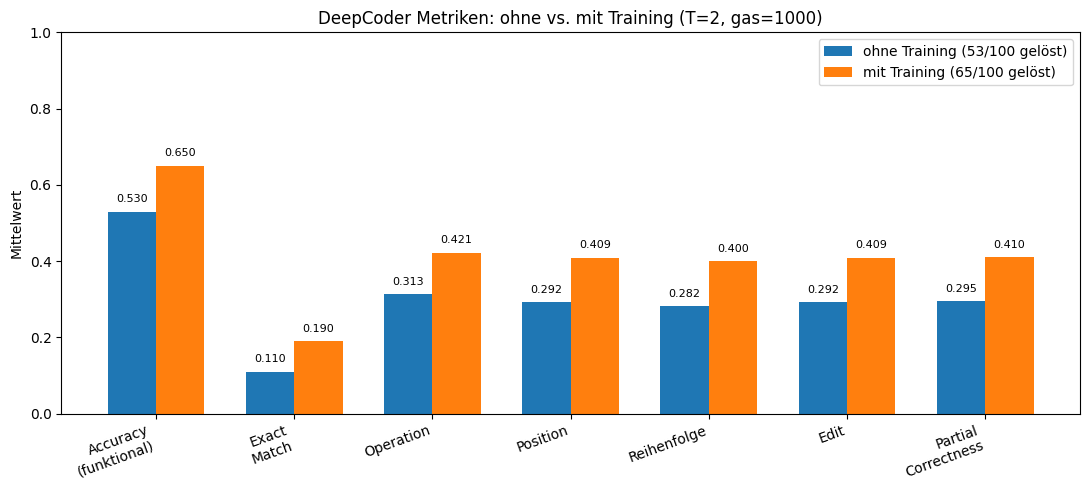

Diagramm gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\metric_comparison_T2_gas1000.png


In [10]:
metrics_plot = [
    "accuracy_functional",
    "accuracy",
    "program_operation_score",
    "program_position_score",
    "program_order_score",
    "program_edit_score",
    "partial_correctness",
]
labels = ["Accuracy\n(funktional)", "Exact\nMatch", "Operation", "Position", "Reihenfolge", "Edit", "Partial\nCorrectness"]

no_pred_vals = metrics_no_pred[metrics_plot].mean().values
with_pred_vals = metrics_with_pred[metrics_plot].mean().values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
n_solved = int(metrics_no_pred["solved"].sum())
w_solved = int(metrics_with_pred["solved"].sum())
bars1 = ax.bar(x - width / 2, no_pred_vals, width, label=f"ohne Training ({n_solved}/{len(metrics_no_pred)} gelöst)")
bars2 = ax.bar(x + width / 2, with_pred_vals, width, label=f"mit Training ({w_solved}/{len(metrics_with_pred)} gelöst)")

ax.set_ylim(0, 1)
ax.set_ylabel("Mittelwert")
ax.set_title(f"DeepCoder Metriken: ohne vs. mit Training (T={T}, gas={GAS})")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plot_path = OUTPUT_DIR / f"metric_comparison_T{T}_gas{GAS}.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Diagramm gespeichert unter:", plot_path)


## Finale Zusammenfassung

In [11]:
summary_lines = [
    "DeepCoder Pipeline Summary",
    "",
    f"T={T}  gas={GAS}  epochs={EPOCHS}  seed={SEED}",
    "",
    f"Ohne Training: {int(metrics_no_pred['solved'].sum())}/{len(metrics_no_pred)} gelöst "
    f"({metrics_no_pred['solved'].mean():.2%}), mean nb_steps={df_no_pred['nb_steps'].mean():.1f}",
    f"Mit Training:  {int(metrics_with_pred['solved'].sum())}/{len(metrics_with_pred)} gelöst "
    f"({metrics_with_pred['solved'].mean():.2%}), mean nb_steps={df_with_pred['nb_steps'].mean():.1f}",
    "",
    "Exakte Programmübereinstimmung (Token-für-Token):",
    f"  ohne Training: {metrics_no_pred['accuracy'].mean():.2%}",
    f"  mit Training:  {metrics_with_pred['accuracy'].mean():.2%}",
    "",
    "Partial Correctness (Mittel aus den 4 Ähnlichkeitsmetriken):",
    f"  ohne Training: {metrics_no_pred['partial_correctness'].mean():.4f}",
    f"  mit Training:  {metrics_with_pred['partial_correctness'].mean():.4f}",
]
summary_text = "\n".join(summary_lines)
print(summary_text)

summary_path = OUTPUT_DIR / f"pipeline_summary_T{T}_gas{GAS}.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print()
print("Zusammenfassung gespeichert unter:", summary_path)


DeepCoder Pipeline Summary

T=2  gas=1000  epochs=10  seed=42

Ohne Training: 53/100 gelöst (53.00%), mean nb_steps=628.4
Mit Training:  65/100 gelöst (65.00%), mean nb_steps=508.9

Exakte Programmübereinstimmung (Token-für-Token):
  ohne Training: 11.00%
  mit Training:  19.00%

Partial Correctness (Mittel aus den 4 Ähnlichkeitsmetriken):
  ohne Training: 0.2948
  mit Training:  0.4097

Zusammenfassung gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\pipeline_summary_T2_gas1000.txt


## Optional: anderes Suchbudget testen

Ändere oben in der Konfigurationszelle z. B.:

```python
GAS = 1000
```

Dann Kernel neu starten und alle Zellen von oben nach unten erneut ausführen — die Ergebnisse landen unter einem eigenen Dateinamen (`results_T2_gas1000_*`), ohne die `gas=10000`-Ergebnisse zu überschreiben.
